# Tugas 2 — Analisis Sinyal Suara & Noise Statis
**Mata Kuliah:** Sistem Teknologi Multimedia (IF25-40305)

**Nama   :** Muhammad Ghama Al Fajri

**NIM    :** 123140182

**Repo   :** https://github.com/Gahehe52/stm-if25-40305-123140182/tree/main/02_audio_noise_statis

## Tentang Tugas Ini
Notebook ini berisi rekaman suara saya sendiri saat membacakan sebuah
berita, sambil ada suara derau (noise) yang terus-menerus di
belakang, seperti kipas angin atau AC. Suara seperti ini disebut
**noise statis**, karena suaranya cenderung sama dari detik ke detik
(tidak naik-turun drastis seperti suara klakson atau ketukan pintu).

Ada dua bagian utama yang saya kerjakan:

1. **Melihat suara dari 4 sudut pandang berbeda** — Waveform, Spektrum
   FFT, Spektrogram STFT, dan Mel-Spektrogram.
2. **Mencoba menurunkan kualitas suara (downsampling)** dengan dua
   cara, lalu membandingkan mana yang menghasilkan suara "rusak"
   (disebut *aliasing*) dan mana yang tidak.



## 1. Merekam Suara & Melihat Info Dasarnya

Saya merekam suara dengan smartphone sambil duduk sekitar 0.5–1 meter
di depan kipas angin/AC, lalu membacakan beberapa kalimat dari
artikel berita. Hasil rekaman disimpan dalam format **WAV**, bukan
MP3, karena format WAV tidak dikompres sehingga suaranya lebih "asli"
dan cocok untuk dianalisis.

Beberapa hal yang dilakukan kode di bawah:
- Audio dibuka dengan `sr=None`, artinya laju sampel (seberapa sering
  suara "difoto" dalam satu detik) **tidak diubah** oleh librosa dan
  tetap sesuai hasil rekaman asli.
- Nama file rekaman sudah saya ubah langsung menjadi
  `audio_original.wav` (bukan disalin lewat kode), supaya namanya
  sesuai dengan aturan penamaan folder tugas.


In [16]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import soundfile as sf
from IPython.display import Audio, display

# --- 1. Path berkas rekaman asli ---
# Berkas rekaman sudah diganti namanya menjadi audio_original.wav
# (sesuai struktur direktori repositori yang diwajibkan), jadi tidak
# perlu ada proses duplikasi/penyimpanan ulang file di dalam notebook.
file_path = "audio_original.wav"

# --- 2. Muat audio dengan sr=None ---
# sr=None artinya librosa TIDAK melakukan resampling otomatis,
# sehingga laju sampel (fs) yang didapat adalah laju sampel asli
# hasil rekaman perangkat (biasanya 44100 Hz atau 48000 Hz).
y, sr = librosa.load(file_path, sr=None)

# --- 3. Ekstraksi metadata dasar sinyal ---
durasi         = len(y) / sr        # total sampel dibagi laju sampel = detik
jumlah_sampel  = len(y)
min_amp        = np.min(y)
max_amp        = np.max(y)
rms_energi     = np.sqrt(np.mean(y**2))   # energi rata-rata (RMS) seluruh sinyal

print("=== Metadata Audio ===")
print(f"Berkas             : {file_path}")
print(f"Durasi Audio       : {durasi:.2f} detik")
print(f"Laju Sampel (fs)   : {sr} Hz")
print(f"Frekuensi Nyquist  : {sr/2:.0f} Hz")
print(f"Total Sampel       : {jumlah_sampel}")
print(f"Amplitudo Minimum  : {min_amp:.5f}")
print(f"Amplitudo Maksimum : {max_amp:.5f}")
print(f"RMS Energi Sinyal  : {rms_energi:.5f}")

# --- 5. Putar audio langsung di notebook (opsional, memudahkan cek) ---
display(Audio(y, rate=sr))


=== Metadata Audio ===
Berkas             : audio_original.wav
Durasi Audio       : 20.08 detik
Laju Sampel (fs)   : 44100 Hz
Frekuensi Nyquist  : 22050 Hz
Total Sampel       : 885517
Amplitudo Minimum  : -0.08868
Amplitudo Maksimum : 0.12265
RMS Energi Sinyal  : 0.01452


**Penjelasan hasil di atas:**
Rekaman saya berdurasi **20.08 detik** dengan laju sampel ($f_s$)
**44100 Hz** — artinya suara "difoto" sebanyak 44.100 kali setiap
detik, sehingga total ada **885.517 sampel/potongan angka** yang
mewakili seluruh suara ini.

Nilai amplitudo tertinggi dan terendah masing-masing adalah **0.12265**
dan **-0.08868**. Karena rentang normal amplitudo adalah -1.0 sampai
1.0, angka ini masih jauh dari batas tersebut. Ini artinya rekaman
saya **tidak pecah/rusak** karena suara terlalu keras (istilah
teknisnya: tidak *clipping*).

Nilai RMS energi (rata-rata kekuatan sinyal) yang saya dapat cukup
kecil, yaitu **0.01452**. Ini masuk akal karena sebagian besar durasi
rekaman hanya berisi suara kipas/AC yang pelan dan konstan, dan hanya
sesekali ada suara saya membaca berita yang lebih keras.


## 2. Melihat Suara dari 4 Sudut Pandang

Satu rekaman suara bisa "dilihat" dengan beberapa cara berbeda, dan
masing-masing cara menunjukkan hal yang berbeda pula:

| # | Nama | Menunjukkan apa? |
|---|---|---|
| 1 | Waveform | Bentuk suara naik-turun terhadap waktu; bisa dipakai membedakan mana bagian hening dan mana bagian saya sedang bicara |
| 2 | Spektrum FFT | Frekuensi apa saja yang ada di dalam suara, dan mana yang paling "kuat" |
| 3 | Spektrogram STFT | Gabungan waktu + frekuensi, jadi kelihatan frekuensi mana yang muncul terus-menerus (noise) dan mana yang berubah-ubah (suara bicara) |
| 4 | Mel-Spektrogram | Mirip spektrogram, tapi disesuaikan dengan cara telinga manusia mendengar, sehingga suara bicara terlihat lebih jelas |

Kode di bawah juga otomatis mencari:
- bagian mana saja yang kemungkinan besar saya sedang bicara (ditandai
  warna oranye di grafik), berdasarkan bagian mana yang suaranya lebih
  "keras" dari rata-rata;
- frekuensi mana yang paling dominan/kuat dari noise statis di
  rekaman saya.


Ambang RMS segmen aktif   : 0.02016
Proporsi waktu 'aktif'    : 15.5% dari total durasi
Frekuensi dominan (noise) : 128.3 Hz


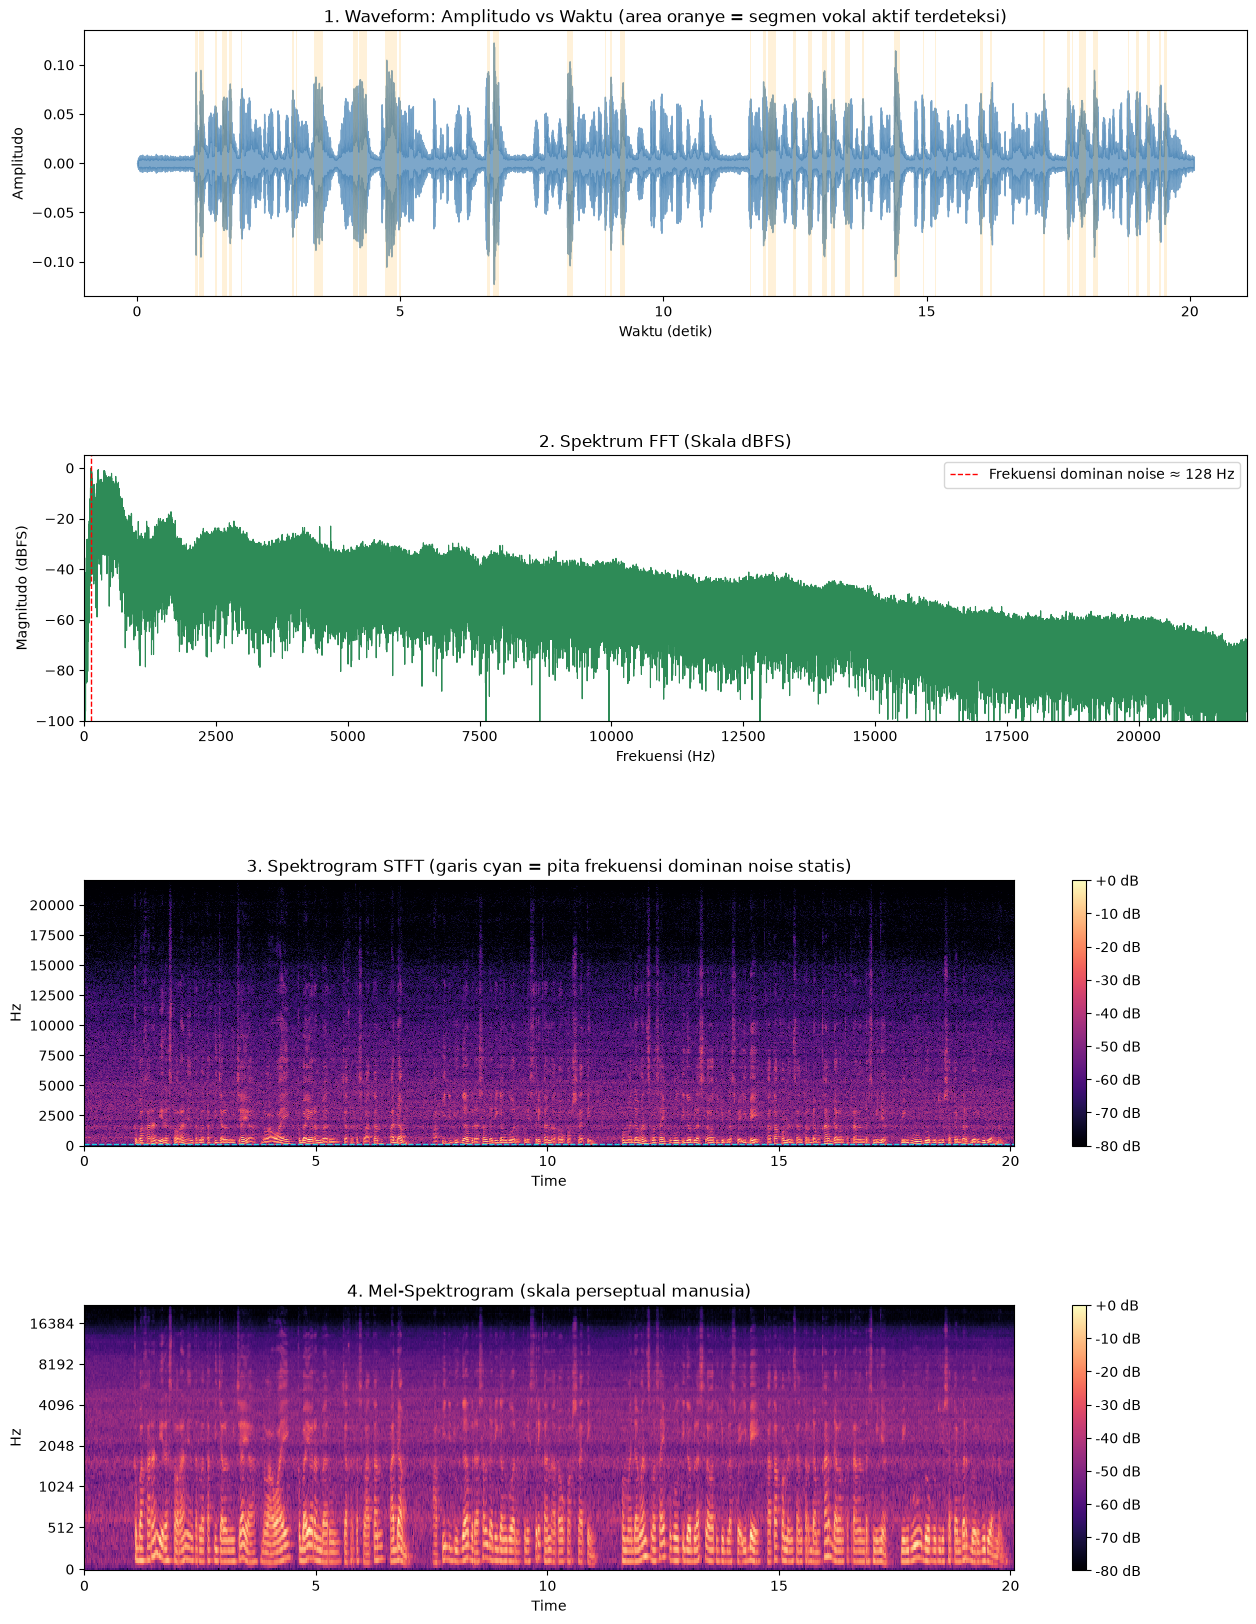

In [17]:
# ======================================================================
# A. WAVEFORM + Deteksi Segmen Hening vs Aktif (berbasis energi RMS)
# ======================================================================
frame_length = 2048
hop_length   = 512

# RMS energi per-frame sepanjang sinyal -> dipakai untuk membedakan
# bagian yang "hanya noise floor" (RMS rendah) dan bagian "vokal aktif"
# (RMS tinggi, karena suara bicara jauh lebih kuat daripada derau kipas/AC).
rms_frame = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
waktu_frame = librosa.frames_to_time(np.arange(len(rms_frame)), sr=sr, hop_length=hop_length)

# Ambang batas (threshold) dipilih otomatis: rata-rata + 1 standar deviasi.
# Frame dengan RMS di atas ambang ini dianggap segmen vokal aktif.
threshold = np.mean(rms_frame) + np.std(rms_frame)
aktif_mask = rms_frame > threshold

# ======================================================================
# B. SPEKTRUM FFT (dBFS) + Deteksi Frekuensi Dominan Noise
# ======================================================================
# rfft cukup dipakai untuk sinyal real-valued -> hanya menghitung
# setengah spektrum positif (0 s.d. Nyquist), lebih efisien daripada fft penuh.
fft_out = np.fft.rfft(y)
freqs   = np.fft.rfftfreq(len(y), d=1/sr)
magnitude = np.abs(fft_out)

# Konversi ke skala dBFS (decibel Full Scale): 20*log10(magnitude/referensi)
# referensi = magnitudo puncak keseluruhan sinyal -> 0 dBFS = puncak sinyal.
# Ditambah epsilon (1e-9) agar tidak terjadi log(0).
magnitude_db = 20 * np.log10(magnitude / np.max(magnitude) + 1e-9)

# Frekuensi dominan = frekuensi dengan magnitudo tertinggi.
# Kita batasi pencarian pada 20 Hz - 2000 Hz agar tidak menangkap
# komponen DC (0 Hz) yang biasanya bukan noise yang relevan.
rentang_cari = (freqs >= 20) & (freqs <= 2000)
idx_dominan  = np.argmax(magnitude[rentang_cari])
freq_dominan = freqs[rentang_cari][idx_dominan]

print(f"Ambang RMS segmen aktif   : {threshold:.5f}")
print(f"Proporsi waktu 'aktif'    : {100*np.mean(aktif_mask):.1f}% dari total durasi")
print(f"Frekuensi dominan (noise) : {freq_dominan:.1f} Hz")

# ======================================================================
# C. PLOTTING 4 REPRESENTASI
# ======================================================================
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

# --- 1. Waveform ---
plt.sca(axes[0])
librosa.display.waveshow(y, sr=sr, color='steelblue', alpha=0.7)
# Beri arsiran hijau pada segmen yang terdeteksi sebagai "vokal aktif"
for t, is_aktif in zip(waktu_frame, aktif_mask):
    if is_aktif:
        axes[0].axvspan(t, t + hop_length/sr, color='orange', alpha=0.15, lw=0)
axes[0].set_title('1. Waveform: Amplitudo vs Waktu (area oranye = segmen vokal aktif terdeteksi)')
axes[0].set_xlabel('Waktu (detik)')
axes[0].set_ylabel('Amplitudo')

# --- 2. Spektrum FFT (dBFS) ---
plt.sca(axes[1])
axes[1].plot(freqs, magnitude_db, color='seagreen', linewidth=0.8)
axes[1].axvline(freq_dominan, color='red', linestyle='--', linewidth=1,
                 label=f'Frekuensi dominan noise \u2248 {freq_dominan:.0f} Hz')
axes[1].set_title('2. Spektrum FFT (Skala dBFS)')
axes[1].set_xlabel('Frekuensi (Hz)')
axes[1].set_ylabel('Magnitudo (dBFS)')
axes[1].set_xlim([0, sr/2])
axes[1].set_ylim([-100, 5])
axes[1].legend(loc='upper right')

# --- 3. Spektrogram STFT ---
plt.sca(axes[2])
D = librosa.stft(y, n_fft=2048, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
img1 = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length,
                                 x_axis='time', y_axis='linear', cmap='magma', ax=axes[2])
# Garis horizontal putus-putus menandai lokasi frekuensi dominan noise statis
axes[2].axhline(freq_dominan, color='cyan', linestyle='--', linewidth=1, alpha=0.8)
axes[2].set_title('3. Spektrogram STFT (garis cyan = pita frekuensi dominan noise statis)')
fig.colorbar(img1, ax=axes[2], format='%+2.0f dB')

# --- 4. Mel-Spektrogram ---
plt.sca(axes[3])
M = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=hop_length)
M_db = librosa.power_to_db(M, ref=np.max)
img2 = librosa.display.specshow(M_db, sr=sr, hop_length=hop_length,
                                 x_axis='time', y_axis='mel', cmap='magma', ax=axes[3])
axes[3].set_title('4. Mel-Spektrogram (skala perseptual manusia)')
fig.colorbar(img2, ax=axes[3], format='%+2.0f dB')

plt.tight_layout(pad=2.5, h_pad=4.0)
fig.subplots_adjust(hspace=0.6)
plt.show()


**Penjelasan hasil visualisasi:**

**(1) Waveform.** Area yang diberi warna oranye adalah bagian yang
terdeteksi sebagai "saya sedang bicara" — berdasarkan hasil hitungan,
ini terjadi sekitar **15.5%** dari total durasi rekaman. Sisanya
(84.5%) adalah bagian hening yang hanya berisi suara kipas/AC. Kalau
diperhatikan, bagian hening ini punya "ketebalan" suara yang hampir
sama terus dari awal sampai akhir — ini ciri khas noise statis, beda
dengan suara saya bicara yang naik-turun mengikuti kalimat.

**(2) Spektrum FFT.** Grafik ini merangkum semua frekuensi yang ada
selama 20 detik rekaman jadi satu gambar. Frekuensi yang paling
dominan (paling "kuat") ada di sekitar **128 Hz**, ditandai garis
merah putus-putus. Frekuensi ini kemungkinan besar berasal dari
dengungan kipas/AC, karena suara mesin berputar biasanya menghasilkan
nada yang cukup rendah dan konstan seperti ini.

**(3) Spektrogram STFT.** Di grafik ini paling kelihatan bedanya:
garis horizontal (ditandai warna cyan) yang membentang rata dari
awal sampai akhir rekaman adalah noise statis dari kipas/AC — karena
suaranya memang tidak berubah dari waktu ke waktu. Sementara itu,
pola yang naik-turun mengikuti waktu adalah suara saya saat membaca
berita, yang nadanya berubah-ubah sesuai kalimat yang saya ucapkan.

**(4) Mel-Spektrogram.** Grafik ini mirip spektrogram sebelumnya,
tapi disusun ulang supaya lebih sesuai dengan cara telinga manusia
mendengar. Efeknya, bagian suara saya yang sedang bicara jadi terlihat
lebih tebal dan jelas dibanding noise di latar belakang, karena
sebagian besar suara bicara manusia memang berada di rentang
frekuensi yang "diperhatikan lebih detail" oleh skala Mel ini.


## 3. Percobaan Menurunkan Kualitas Suara (Resampling) & Aliasing

Rekaman asli saya punya laju sampel **44100 Hz**. Di bagian ini, saya
mencoba menurunkannya menjadi **8000 Hz** (lebih rendah = ukuran file
lebih kecil, tapi berisiko kualitas suara menurun), dan saya coba
dengan dua cara berbeda supaya bisa dibandingkan:

- **Cara A — Naive Decimation.** Cara paling sederhana, yaitu tinggal
  "mengambil" satu dari setiap beberapa sampel, sisanya dibuang
  begitu saja, tanpa ada persiapan khusus sebelumnya. Karena tidak
  ada penyaringan dulu, suara yang frekuensinya terlalu tinggi untuk
  laju sampel baru ini malah "bocor" dan tercampur balik dengan
  frekuensi rendah, membuat suara jadi kacau. Efek rusak seperti ini
  disebut **aliasing**.
- **Cara B — Resampling Standar.** Menggunakan fungsi `librosa.resample`,
  yang secara otomatis menyaring dulu frekuensi tinggi yang berpotensi
  bermasalah, sebelum benar-benar menurunkan laju sampelnya. Karena
  ada penyaringan ini, hasilnya jauh lebih rapi.

Selain melihat gambarnya, saya juga menghitung angka energi suara
pada rentang frekuensi tertentu untuk membuktikan bedanya secara
angka, bukan cuma dugaan visual saja.


In [18]:
# --- 1. Tentukan target laju sampel & faktor decimation ---
target_sr = 8000

# int() pada pembagian float bisa mengalami floating point error (mis.
# 44100/8000 = 5.5125 -> int() = 5, benar), tapi untuk keamanan kita
# gunakan pembulatan eksplisit dengan round() lalu pastikan minimal 1.
decimation_factor = max(1, round(sr / target_sr))
print(f"Laju sampel asli       : {sr} Hz")
print(f"Target laju sampel     : {target_sr} Hz")
print(f"Faktor decimation (M)  : {decimation_factor}")
print(f"Nyquist target ({target_sr} Hz)  : {target_sr/2:.0f} Hz  <- batas frekuensi aman tanpa aliasing")

# ======================================================================
# Skenario A: Naive Decimation (TANPA filter anti-aliasing)
# ======================================================================
# Mengambil setiap sampel ke-M langsung dari sinyal asli.
# Tidak ada LPF sebelumnya -> semua komponen frekuensi > Nyquist baru
# (4000 Hz) akan "terlipat" (fold-back) ke frekuensi yang lebih rendah.
y_naive = y[::decimation_factor]
sf.write('audio_downsampled_naive.wav', y_naive, target_sr)

# ======================================================================
# Skenario B: Resampling standar (DENGAN filter anti-aliasing)
# ======================================================================
# librosa.resample menerapkan filter low-pass anti-aliasing (berbasis
# polyphase filtering / resampy) sebelum menurunkan laju sampel,
# sehingga komponen frekuensi di atas Nyquist baru dibuang lebih dulu.
y_clean = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
sf.write('audio_downsampled_clean.wav', y_clean, target_sr)

print(f"\nPanjang sinyal naive  : {len(y_naive)} sampel")
print(f"Panjang sinyal clean  : {len(y_clean)} sampel")

# --- Putar ketiga versi audio untuk perbandingan kualitatif ---
print("\nAudio asli:")
display(Audio(y, rate=sr))
print("Audio naive decimation (berpotensi terdengar berisik/pecah akibat aliasing):")
display(Audio(y_naive, rate=target_sr))
print("Audio resampling standar (anti-aliasing):")
display(Audio(y_clean, rate=target_sr))


Laju sampel asli       : 44100 Hz
Target laju sampel     : 8000 Hz
Faktor decimation (M)  : 6
Nyquist target (8000 Hz)  : 4000 Hz  <- batas frekuensi aman tanpa aliasing

Panjang sinyal naive  : 147587 sampel
Panjang sinyal clean  : 160639 sampel

Audio asli:


Audio naive decimation (berpotensi terdengar berisik/pecah akibat aliasing):


Audio resampling standar (anti-aliasing):


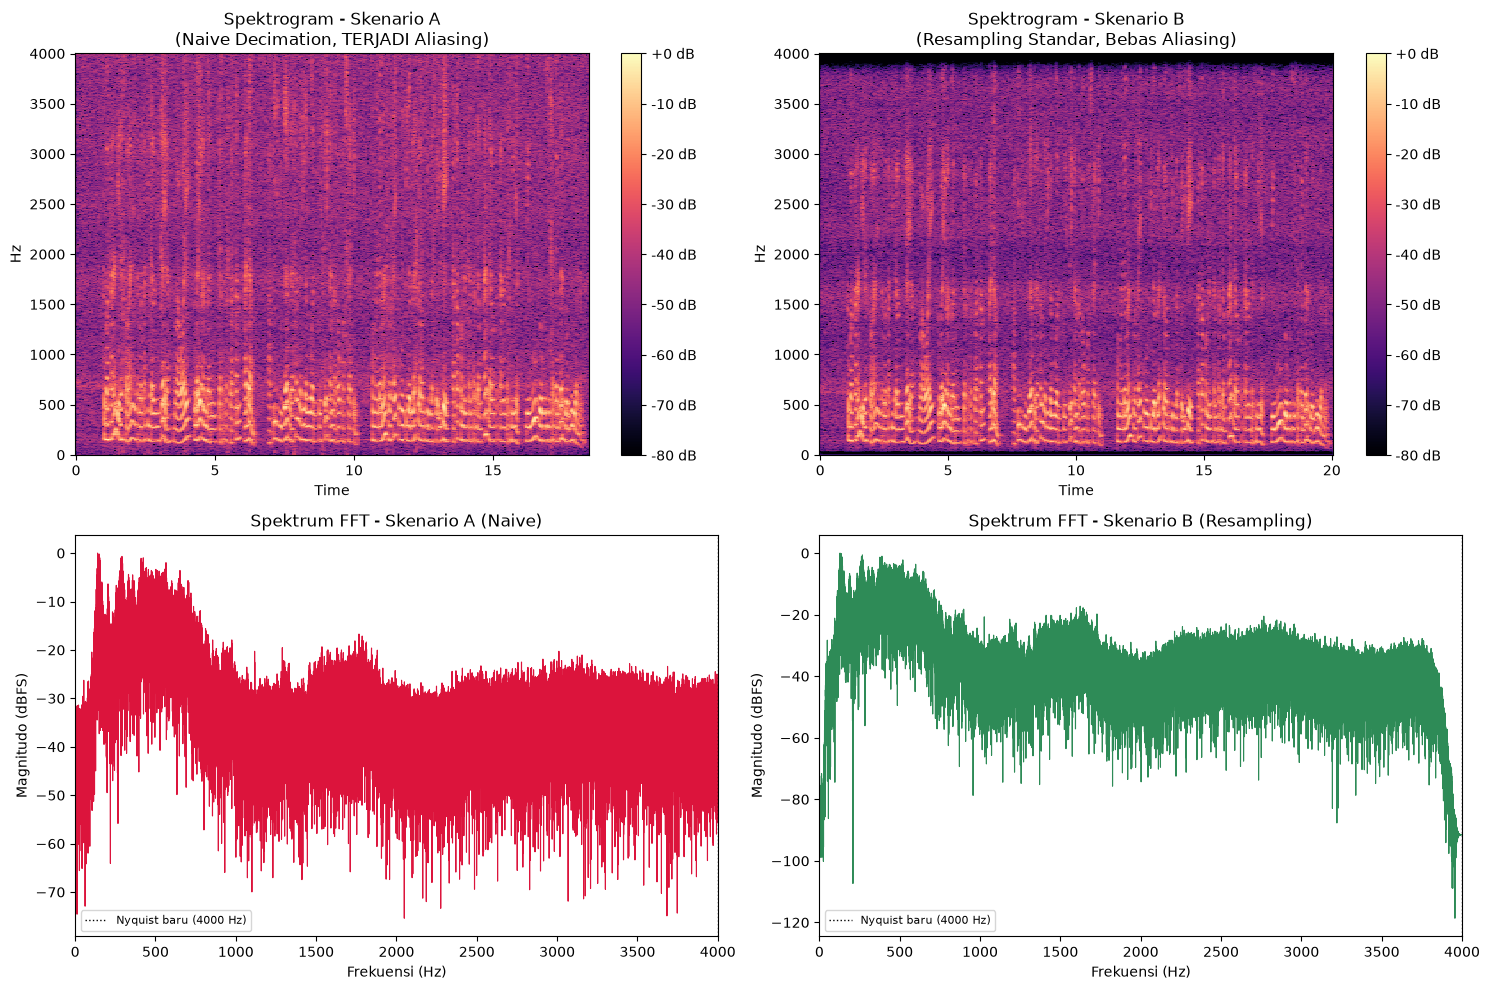

Energi pita 1500-4000 Hz | Skenario A (naive) : 102853.7500
Energi pita 1500-4000 Hz | Skenario B (clean)  : 77104.0391
Rasio energi A/B                                : 1.33x


In [19]:
# ======================================================================
# Visualisasi Komparasi: Spektrogram + Spektrum FFT
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Spektrogram Skenario A (naive) ---
D_naive = librosa.stft(y_naive)
S_naive_db = librosa.amplitude_to_db(np.abs(D_naive), ref=np.max)
img_a = librosa.display.specshow(S_naive_db, sr=target_sr, x_axis='time',
                                  y_axis='linear', cmap='magma', ax=axes[0, 0])
axes[0, 0].set_title('Spektrogram - Skenario A\n(Naive Decimation, TERJADI Aliasing)')
fig.colorbar(img_a, ax=axes[0, 0], format='%+2.0f dB')

# --- Spektrogram Skenario B (resampling terfilter) ---
D_clean = librosa.stft(y_clean)
S_clean_db = librosa.amplitude_to_db(np.abs(D_clean), ref=np.max)
img_b = librosa.display.specshow(S_clean_db, sr=target_sr, x_axis='time',
                                  y_axis='linear', cmap='magma', ax=axes[0, 1])
axes[0, 1].set_title('Spektrogram - Skenario B\n(Resampling Standar, Bebas Aliasing)')
fig.colorbar(img_b, ax=axes[0, 1], format='%+2.0f dB')

# --- Spektrum FFT pembanding (skala dBFS) untuk kedua skenario ---
for ax, sig, judul, warna in [
    (axes[1, 0], y_naive, 'Spektrum FFT - Skenario A (Naive)', 'crimson'),
    (axes[1, 1], y_clean, 'Spektrum FFT - Skenario B (Resampling)', 'seagreen'),
]:
    f_out = np.fft.rfft(sig)
    f_freqs = np.fft.rfftfreq(len(sig), d=1/target_sr)
    f_mag_db = 20 * np.log10(np.abs(f_out) / (np.max(np.abs(f_out)) + 1e-12) + 1e-9)
    ax.plot(f_freqs, f_mag_db, color=warna, linewidth=0.8)
    ax.axvline(target_sr/2, color='black', linestyle=':', linewidth=1,
               label=f'Nyquist baru ({target_sr/2:.0f} Hz)')
    ax.set_title(judul)
    ax.set_xlabel('Frekuensi (Hz)')
    ax.set_ylabel('Magnitudo (dBFS)')
    ax.set_xlim([0, target_sr/2])
    ax.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

# --- Bukti kuantitatif tambahan: energi pada pita frekuensi menengah-atas ---
# Pita 1500-4000 Hz dipakai sebagai indikator: pada sinyal yang di-filter
# dengan benar (Skenario B), energi di pita ini seharusnya jauh lebih
# rendah/halus dibanding sinyal naive yang berpotensi memuat energi hasil
# lipatan (aliasing) dari frekuensi asli di atas Nyquist baru.
def energi_pita(sinyal, sr_sinyal, f_low, f_high):
    spek = np.abs(np.fft.rfft(sinyal))
    fr = np.fft.rfftfreq(len(sinyal), d=1/sr_sinyal)
    mask = (fr >= f_low) & (fr <= f_high)
    return np.sum(spek[mask]**2)

e_naive = energi_pita(y_naive, target_sr, 1500, 4000)
e_clean = energi_pita(y_clean, target_sr, 1500, 4000)
print(f"Energi pita 1500-4000 Hz | Skenario A (naive) : {e_naive:.4f}")
print(f"Energi pita 1500-4000 Hz | Skenario B (clean)  : {e_clean:.4f}")
print(f"Rasio energi A/B                                : {e_naive / (e_clean + 1e-12):.2f}x")


**Penjelasan hasil percobaan:**

Rekaman asli saya (44100 Hz) sebenarnya bisa menyimpan frekuensi
sampai sekitar 22050 Hz. Tapi setelah diturunkan ke 8000 Hz, laju
sampel yang baru ini cuma "sanggup" menyimpan frekuensi sampai
4000 Hz dengan aman. Nah, di **Cara A (Naive Decimation)**, karena
tidak ada penyaringan dulu, semua frekuensi yang lebih tinggi dari
4000 Hz (baik dari suara kipas/AC maupun suara desis saat saya
bicara) tidak dibuang, melainkan "terpental" dan bercampur ke
frekuensi yang lebih rendah. Inilah yang disebut aliasing.

Buktinya bisa dilihat dari angka energi yang saya hitung pada
frekuensi 1500–4000 Hz: pada Cara A angkanya lebih tinggi
(**102.853,75**) dibanding Cara B (**77.104,04**), dengan selisih
sekitar **1.33 kali lebih besar**. Artinya, di Cara A memang ada
tambahan "suara asing" yang seharusnya tidak ada — hasil dari
frekuensi tinggi yang terpental tadi. Kalau didengarkan langsung,
hasil audio Cara A juga cenderung terdengar lebih kasar/berisik
dibanding Cara B.

Sebaliknya, di **Cara B (Resampling Standar)**, karena frekuensi
tinggi sudah disaring dan dibuang lebih dulu sebelum diturunkan
lajunya, hasil akhirnya jauh lebih bersih — baik dilihat dari
grafik spektrogramnya maupun didengar langsung suaranya.

**Kesimpulannya:** kalau mau menurunkan laju sampel suara, jangan
langsung asal "buang sampel" begitu saja (Cara A), karena bisa
merusak suara dengan cara yang tidak bisa diperbaiki lagi setelahnya.
Cara yang benar adalah menyaring dulu frekuensi tingginya sebelum
diturunkan (Cara B), seperti yang dilakukan otomatis oleh
`librosa.resample`.
